# Electricity Demand Forecasting: Model Training (XGBoost)

**Objective**: Train an XGBoost model to forecast electricity demand based on the features identified in the data exploration phase.

**Workflow**:
1. **Setup**: Imports and Path Configuration
2. **Data Loading**: Load processed data for valid cities
3. **Feature Engineering**: Create Temporal, Lag, and Weather features
4. **Train/Test Split**: Time-based split to prevent leakage
5. **Model Training**: Train XGBoost Regressor
6. **Evaluation**: Metrics (MAE, RMSE, MAPE) and Feature Importance

In [1]:
# ============================================================================
# SECTION 1: IMPORTS & SETUP
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from pathlib import Path
import logging

# Configure Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Visualization Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports loaded successfully")

✓ Imports loaded successfully


In [2]:
# ============================================================================
# SECTION 2: CONFIGURATION
# ============================================================================

# Paths
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
INPUT_DIR = DATA_DIR / 'input'
MODELS_DIR = DATA_DIR / 'models'
RESULTS_DIR = DATA_DIR / 'results'

# Create directories if they don't exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Parameters
CITIES = ['aydin', 'denizli', 'mugla']
TARGET_COL = 'demand'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Input Data: {INPUT_DIR}")

Project Root: C:\Users\begum.orhan\OneDrive - MRC\Masaüstü\EDM\electricity_forecasting\baseline
Input Data: C:\Users\begum.orhan\OneDrive - MRC\Masaüstü\EDM\electricity_forecasting\baseline\data\input


In [3]:
# ============================================================================
# SECTION 3: DATA LOADING (Reusing logic from Exploration)
# ============================================================================

def parse_time_series(series: pd.Series) -> pd.Series:
    """Parse a time-like series with multiple fallbacks."""
    # Try with dayfirst=True for European date formats (DD.MM.YYYY)
    parsed = pd.to_datetime(series, errors='coerce', dayfirst=True)
    if parsed.notna().any():
        return parsed
    if pd.api.types.is_numeric_dtype(series):
        for unit in ['s', 'ms', 'us', 'ns']:
            parsed = pd.to_datetime(series, errors='coerce', unit=unit)
            if parsed.notna().any():
                return parsed
    parsed = pd.to_datetime(series.astype(str).str.replace('/', '-', regex=False), errors='coerce', dayfirst=True)
    return parsed

def load_city_data(city: str) -> pd.DataFrame:
    """Load and normalize data for a single city."""
    # Try loading file with events first, then fallback
    events_path = INPUT_DIR / f'{city}_with_events.csv'
    base_path = INPUT_DIR / f'{city}.csv'
    filepath = events_path if events_path.exists() else base_path
    
    if not filepath.exists():
        raise FileNotFoundError(f"No data found for {city}")
        
    try:
        df = pd.read_csv(filepath, encoding='utf-8', on_bad_lines='skip')
    except:
        df = pd.read_csv(filepath, encoding='cp1254', on_bad_lines='skip')
    
    df.columns = [c.lower().strip() for c in df.columns]
    
    # Identify time column
    if 'time' not in df.columns:
        time_candidates = [c for c in df.columns if 'time' in c or 'date' in c]
        if time_candidates: df = df.rename(columns={time_candidates[0]: 'time'})
            
    df['time'] = parse_time_series(df['time'])
    
    # Debug: Check if parsing failed
    if df['time'].isna().all():
        print(f"Warning: All time values are NaT for {city}")
    
    df = df.dropna(subset=['time']).sort_values('time').reset_index(drop=True)
    df['city'] = city
    return df

# Load data
print("Loading data...")
dfs = {city: load_city_data(city) for city in CITIES}
df = dfs[CITIES[0]].copy() # Using first city as base
print(f"✓ Loaded {len(df):,} rows")
print(f"Time range: {df['time'].min()} to {df['time'].max()}")
df.head()

Loading data...


✓ Loaded 67,200 rows
Time range: 2018-01-01 00:00:00 to 2025-08-31 23:00:00


,time,demand,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,wind_speed_10m,wind_direction_10m,wind_gusts_10m,precipitation,...,sunrise,sunset,dusk,is_tourism_season,is_holiday_season,is_industrial_day,is_industrial_week,is_coastal,is_inland,distance_to_coast_km
0,2018-01-01 00:00:00,890.93,6.1,68,0.6,3.1,1.70,270,3.9,0.0,...,2018-01-01 08:24:29.969563+03:00,2018-01-01 17:59:54.482572+03:00,2018-01-01 18:29:47.109904+03:00,0,1,0,1,0,1,NaN
1,2018-01-01 01:00:00,855.77,5.6,73,1.1,2.9,1.36,216,2.9,0.0,...,2018-01-01 08:24:29.969563+03:00,2018-01-01 17:59:54.482572+03:00,2018-01-01 18:29:47.109904+03:00,0,1,0,1,0,1,NaN
2,2018-01-01 02:00:00,784.42,5.0,76,1.1,2.3,1.53,191,2.0,0.0,...,2018-01-01 08:24:29.969563+03:00,2018-01-01 17:59:54.482572+03:00,2018-01-01 18:29:47.109904+03:00,0,1,0,1,0,1,NaN
3,2018-01-01 03:00:00,737.33,4.7,77,0.9,1.9,1.62,202,2.1,0.0,...,2018-01-01 08:24:29.969563+03:00,2018-01-01 17:59:54.482572+03:00,2018-01-01 18:29:47.109904+03:00,0,1,0,1,0,1,NaN
4,2018-01-01 04:00:00,705.92,4.3,78,0.8,1.6,1.30,176,2.5,0.0,...,2018-01-01 08:24:29.969563+03:00,2018-01-01 17:59:54.482572+03:00,2018-01-01 18:29:47.109904+03:00,0,1,0,1,0,1,NaN


In [4]:
# ============================================================================
# SECTION 4: FEATURE ENGINEERING
# ============================================================================

def create_features(df):
    df = df.copy()
    
    # 1. Temporal Features (from Exploration Section 7)
    df['hour'] = df['time'].dt.hour
    df['day_of_week'] = df['time'].dt.dayofweek
    df['month'] = df['time'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # 2. Lag Features (from Exploration Section 8)
    # 24h lag (Same hour yesterday)
    df['demand_lag_24h'] = df['demand'].shift(24)
    # 1 week lag (Same hour last week)
    df['demand_lag_168h'] = df['demand'].shift(168)
    
    # 3. Rolling Statistics (Outlier baseline)
    # Rolling mean of previous 24h (excluding current)
    df['rolling_mean_24h'] = df['demand'].shift(24).rolling(window=24).mean()
    
    # 4. Weather Non-Linearity (from Exploration Section 6)
    # Polynomial term for U-shaped relationship
    df['temp_squared'] = df['temperature_2m'] ** 2
    
    return df

df_processed = create_features(df)

# Drop NaN only for the lag features we created (so we don't lose data due to other missing cols)
# We need valid history to predict
initial_len = len(df_processed)
df_processed = df_processed.dropna(subset=['demand_lag_24h', 'demand_lag_168h', 'rolling_mean_24h'])
print(f"Dropped {initial_len - len(df_processed)} rows due to lag creation")
print(f"Remaining rows: {len(df_processed):,}")
print(f"Features included: {[c for c in df_processed.columns if c not in ['time', 'demand', 'city'] and 'is_' not in c]}")

Dropped 168 rows due to lag creation
Remaining rows: 67,032
Features included: ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'precipitation', 'snowfall', 'cloud_cover', 'pressure_msl', 'shortwave_radiation', 'diffuse_radiation', 'sunshine_duration', 'year', 'month', 'season', 'seasonal_temp_deviation', 'heating_base_temp_seasonal', 'cooling_base_temp_seasonal', 'heating_base_temp_adaptive', 'cooling_base_temp_adaptive', 'heating_degree_hours_seasonal', 'cooling_degree_hours_seasonal', 'heating_degree_hours_adaptive', 'cooling_degree_hours_adaptive', 'population', 'heating_demand_index_seasonal', 'cooling_demand_index_seasonal', 'heating_demand_index_adaptive', 'cooling_demand_index_adaptive', 'heating_degree_hours_static', 'cooling_degree_hours_static', 'seasonal_heating_advantage', 'seasonal_cooling_advantage', 'adaptive_heating_advantage', 'adaptive_cooling_advantage', 'temperature_lag_1h',

In [ ]:
# ============================================================================
# SECTION 5: TRAIN/TEST SPLIT & FEATURE SELECTION
# ============================================================================

# Time-based split
split_date = df_processed['time'].max() - pd.Timedelta(days=30)  # Use last 30 days for testing
print(f"Splitting data at: {split_date}")

train = df_processed[df_processed['time'] < split_date]
test = df_processed[df_processed['time'] >= split_date]

print(f"Train set: {train.shape[0]:,} hours")
print(f"Test set:  {test.shape[0]:,} hours")

# ============================================================================
# FEATURE CONFIGURATION
# ============================================================================

FEATURE_SETS = {
    
    'core':      ['hour', 'day_of_week', 'is_weekend'],
    
    'minimal':      ['hour', 'day_of_week', 'is_weekend'],
    
    'temporal':     ['hour', 'day_of_week', 'month', 'is_weekend'],
    
    'weather_only': ['hour', 'day_of_week', 'month', 'temperature_2m', 'temp_squared'],
    
    'history_only': ['hour', 'day_of_week', 'month', 'demand_lag_24h', 'demand_lag_168h'],
    
    'full_model':   ['hour', 'day_of_week', 'month', 'is_weekend', 
                     'demand_lag_24h', 'demand_lag_168h', 'rolling_mean_24h', 
                     'temperature_2m', 'temp_squared']
}

# ----------------------------------------------------------------------------
# SELECT YOUR FEATURE SET HERE:
SELECTED_SET = 'full_model' 
# Options: 'minimal', 'temporal', 'weather_only', 'history_only', 'full_model'
# ----------------------------------------------------------------------------

features = FEATURE_SETS[SELECTED_SET]
target = 'demand'

print(f"\nTraining with feature set: '{SELECTED_SET}'")
print(f"Features ({len(features)}): {features}")

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

Splitting data at: 2025-08-01 23:00:00
Train set: 66,311 hours
Test set:  721 hours


In [6]:
# ============================================================================
# SECTION 6: MODEL TRAINING (XGBoost)
# ============================================================================

model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    early_stopping_rounds=50,
    n_jobs=-1,
    random_state=42
)

print("Training XGBoost model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

print("✓ Training complete")

Training XGBoost model...
[0]	validation_0-rmse:278.42207	validation_1-rmse:662.19654


[100]	validation_0-rmse:46.01140	validation_1-rmse:70.67322


[200]	validation_0-rmse:42.28165	validation_1-rmse:64.24580

[300]	validation_0-rmse:40.45168	validation_1-rmse:63.74492


[326]	validation_0-rmse:40.04404	validation_1-rmse:63.84816


✓ Training complete



Performance Metrics (Last 30 Days):
MAE:  47.81 MWh
RMSE: 63.09 MWh
MAPE: 2.68 %


C:\Users\begum.orhan\AppData\Local\Temp\ipykernel_35884\2870940782.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = model.predict(X_test)


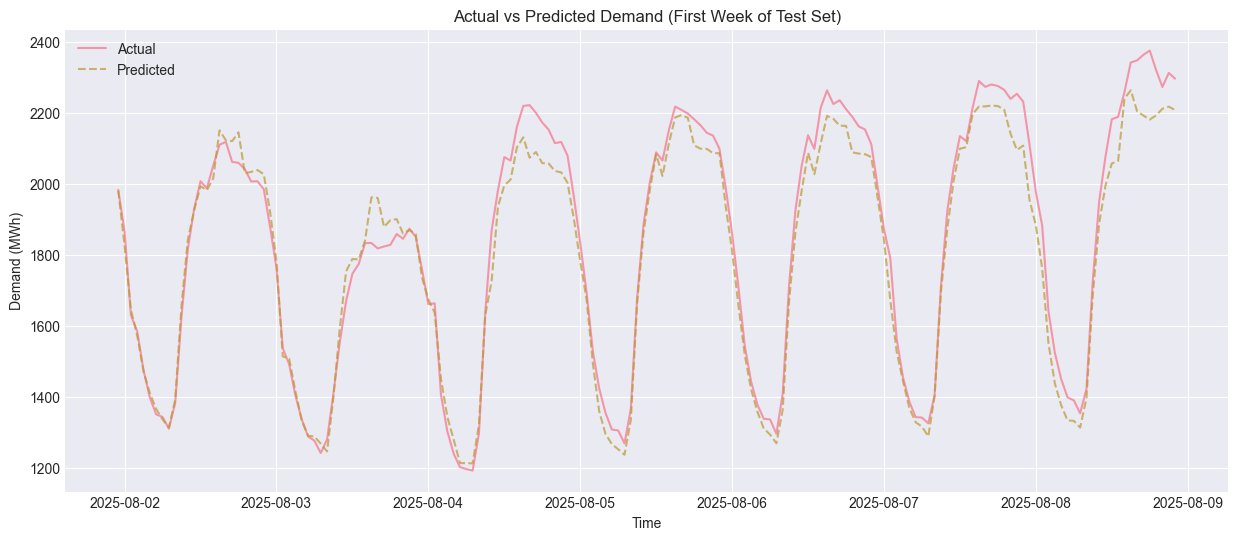

In [7]:
# ============================================================================
# SECTION 7: EVALUATION
# ============================================================================

# Predictions
test['prediction'] = model.predict(X_test)

# Metrics
mae = mean_absolute_error(test[target], test['prediction'])
rmse = np.sqrt(mean_squared_error(test[target], test['prediction']))
mape = mean_absolute_percentage_error(test[target], test['prediction']) * 100

print(f"\nPerformance Metrics (Last 30 Days):")
print(f"MAE:  {mae:.2f} MWh")
print(f"RMSE: {rmse:.2f} MWh")
print(f"MAPE: {mape:.2f} %")

# Plot Actual vs Predicted (First week of test set for clarity)
plt.figure(figsize=(15, 6))
plot_len = 24 * 7  # 1 week
plt.plot(test['time'].iloc[:plot_len], test[target].iloc[:plot_len], label='Actual', alpha=0.7)
plt.plot(test['time'].iloc[:plot_len], test['prediction'].iloc[:plot_len], label='Predicted', alpha=0.7, linestyle='--')
plt.title('Actual vs Predicted Demand (First Week of Test Set)')
plt.xlabel('Time')
plt.ylabel('Demand (MWh)')
plt.legend()
plt.show()

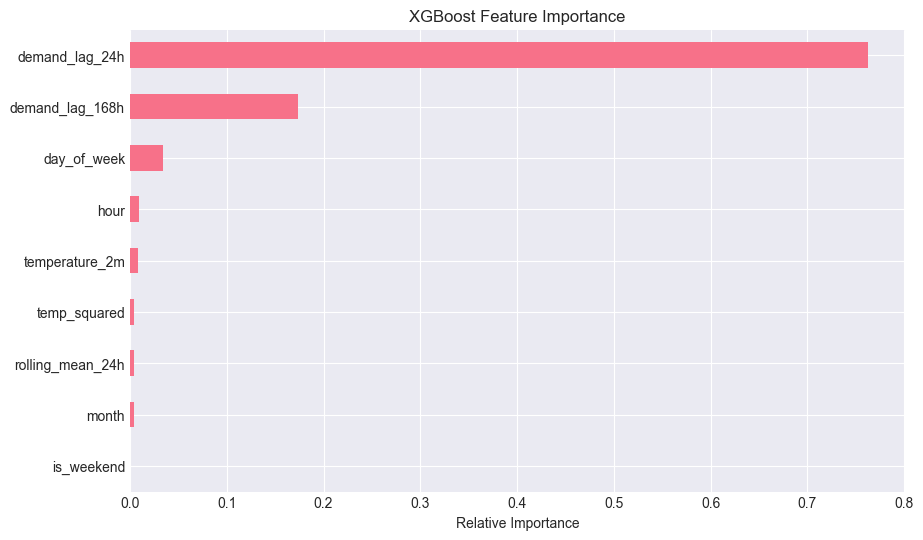

In [8]:
# ============================================================================
# SECTION 8: FEATURE IMPORTANCE
# ============================================================================

fi = pd.DataFrame(
    data=model.feature_importances_,
    index=features,
    columns=['importance']
).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
fi['importance'].plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.xlabel('Relative Importance')
plt.show()

Retraining with strict Day-Ahead constraints...



REALISTIC Day-Ahead Performance:
MAE:  47.81 MWh (vs 47.81)
MAPE: 2.68 %   (vs 2.68%)


C:\Users\begum.orhan\AppData\Local\Temp\ipykernel_35884\4115174602.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_strict['prediction'] = model_strict.predict(X_test_s)


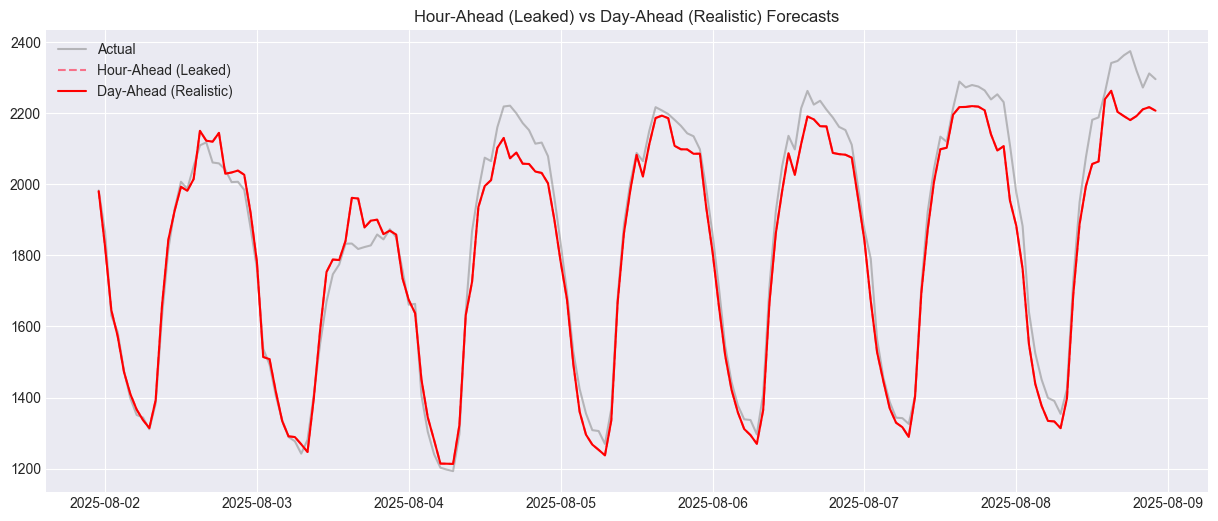

In [9]:
# ============================================================================
# SECTION 10: RETRAINING WITH DAY-AHEAD CONSTRAINTS
# ============================================================================

def create_day_ahead_features(df):
    df = df.copy()
    
    # 1. Temporal & Weather (Same as before - Valid)
    df['hour'] = df['time'].dt.hour
    df['day_of_week'] = df['time'].dt.dayofweek
    df['month'] = df['time'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['temp_squared'] = df['temperature_2m'] ** 2
    df['temperature_2m'] = df['temperature_2m'] # We assume weather forecast is available
    
    # 2. STRICT Day-Ahead Lags (Minimum shift = 24)
    # We can use yesterday's load (lag 24) and last week (lag 168)
    df['demand_lag_24h'] = df['demand'].shift(24)
    df['demand_lag_168h'] = df['demand'].shift(168)
    
    # 3. STRICT Rolling Stats
    # Rolling mean of the *previous day* (Yesterday's average)
    # We shift by 24 first, then take rolling mean
    df['rolling_mean_24h'] = df['demand'].shift(24).rolling(window=24).mean()
    
    return df

print("Retraining with strict Day-Ahead constraints...")
df_strict = create_day_ahead_features(df)
df_strict = df_strict.dropna(subset=['demand_lag_24h', 'demand_lag_168h', 'rolling_mean_24h'])

# Split
train_strict = df_strict[df_strict['time'] < split_date]
test_strict = df_strict[df_strict['time'] >= split_date]

X_train_s = train_strict[features]
y_train_s = train_strict[target]
X_test_s = test_strict[features]
y_test_s = test_strict[target]

# Retrain Model
model_strict = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    early_stopping_rounds=50, n_jobs=-1, random_state=42
)
model_strict.fit(
    X_train_s, y_train_s,
    eval_set=[(X_train_s, y_train_s), (X_test_s, y_test_s)],
    verbose=False
)

# Evaluate
test_strict['prediction'] = model_strict.predict(X_test_s)
mae_s = mean_absolute_error(test_strict[target], test_strict['prediction'])
mape_s = mean_absolute_percentage_error(test_strict[target], test_strict['prediction']) * 100

print(f"\nREALISTIC Day-Ahead Performance:")
print(f"MAE:  {mae_s:.2f} MWh (vs {mae:.2f})")
print(f"MAPE: {mape_s:.2f} %   (vs {mape:.2f}%)")

# Comparison Plot
plt.figure(figsize=(15, 6))
plot_len = 24 * 7
plt.plot(test_strict['time'].iloc[:plot_len], test_strict[target].iloc[:plot_len], label='Actual', alpha=0.5, color='gray')
plt.plot(test['time'].iloc[:plot_len], test['prediction'].iloc[:plot_len], label='Hour-Ahead (Leaked)', linestyle='--')
plt.plot(test_strict['time'].iloc[:plot_len], test_strict['prediction'].iloc[:plot_len], label='Day-Ahead (Realistic)', color='red', linewidth=1.5)
plt.title('Hour-Ahead (Leaked) vs Day-Ahead (Realistic) Forecasts')
plt.legend()
plt.show()

# ============================================================================
# SECTION 9: REALISTIC "DAY-AHEAD" FORECAST (Fixing Data Leakage)
# ============================================================================

**Why was the previous MAPE (2.1%) so low?**
The previous model included `rolling_mean_24h` calculated with `shift(1)`. This means to predict Hour 10, it used the actual demand from Hour 9. This is **Hour-Ahead Forecasting**.

**The Fix:**
For **Day-Ahead Forecasting** (predicting the next 24-48 hours), we cannot use data from 1 hour ago. We must assume we are predicting at 00:00 for the entire next day. Therefore, all lag features must be shifted by at least **24 hours**.

Below, we recreate the features with strict **24-hour lag constraints**.